# Student Dropout Prediction Project
## Notebook 01: Data Loading, Cleaning and Exploratory Data Analysis

### Objective

This notebook contains the first stage of my student dropout prediction project.

The purpose of this stage is to understand the dataset before building machine learning models.

The analysis covers:

1. Dataset structure
2. Data quality
3. Target distribution
4. Student demographics
5. Admission and academic background
6. Financial variables
7. Course-level dropout patterns
8. First-semester academic performance
9. Second-semester academic performance
10. Macroeconomic variables
11. Relationships between variables
12. Initial statistical tests
13. Definition of prediction stages

The target variable contains three outcomes:

- Dropout
- Enrolled
- Graduate

Therefore, the eventual prediction problem will be a multiclass classification problem.


## 1. Import libraries

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

print("Libraries loaded successfully.")


Libraries loaded successfully.


## 2. Load the dataset

In [51]:
df = pd.read_csv("../data/raw/student_dropout.csv")

print("Number of students:", df.shape[0])
print("Number of columns:", df.shape[1])


Number of students: 4424
Number of columns: 37


In [52]:
display(df.head())

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
0,1,17,5,171,1,1,122.00,1,19,12,5,9,127.30,1,0,0,1,1,0,20,0,0,0,0,0,0.00,0,0,0,0,0,0.00,0,10.80,1.40,1.74,Dropout
1,1,15,1,9254,1,1,160.00,1,1,3,3,3,142.50,1,0,0,0,1,0,19,0,0,6,6,6,14.00,0,0,6,6,6,13.67,0,13.90,-0.30,0.79,Graduate
2,1,1,5,9070,1,1,122.00,1,37,37,9,9,124.80,1,0,0,0,1,0,19,0,0,6,0,0,0.00,0,0,6,0,0,0.00,0,10.80,1.40,1.74,Dropout
3,1,17,2,9773,1,1,122.00,1,38,37,5,3,119.60,1,0,0,1,0,0,20,0,0,6,8,6,13.43,0,0,6,10,5,12.40,0,9.40,-0.80,-3.12,Graduate
4,2,39,1,8014,0,1,100.00,1,37,38,9,9,141.50,0,0,0,1,0,0,45,0,0,6,9,5,12.33,0,0,6,6,6,13.00,0,13.90,-0.30,0.79,Graduate


In [53]:
display(df.tail())

,Marital Status,Application mode,Application order,Course,Daytime/evening attendance,Previous qualification,Previous qualification (grade),Nacionality,Mother's qualification,Father's qualification,Mother's occupation,Father's occupation,Admission grade,Displaced,Educational special needs,Debtor,Tuition fees up to date,Gender,Scholarship holder,Age at enrollment,International,Curricular units 1st sem (credited),Curricular units 1st sem (enrolled),Curricular units 1st sem (evaluations),Curricular units 1st sem (approved),Curricular units 1st sem (grade),Curricular units 1st sem (without evaluations),Curricular units 2nd sem (credited),Curricular units 2nd sem (enrolled),Curricular units 2nd sem (evaluations),Curricular units 2nd sem (approved),Curricular units 2nd sem (grade),Curricular units 2nd sem (without evaluations),Unemployment rate,Inflation rate,GDP,Target
4419,1,1,6,9773,1,1,125.00,1,1,1,5,4,122.20,0,0,0,1,1,0,19,0,0,6,7,5,13.60,0,0,6,8,5,12.67,0,15.50,2.80,-4.06,Graduate
4420,1,1,2,9773,1,1,120.00,105,1,1,9,9,119.00,1,0,1,0,0,0,18,1,0,6,6,6,12.00,0,0,6,6,2,11.00,0,11.10,0.60,2.02,Dropout
4421,1,1,1,9500,1,1,154.00,1,37,37,9,9,149.50,1,0,0,1,0,1,30,0,0,7,8,7,14.91,0,0,8,9,1,13.50,0,13.90,-0.30,0.79,Dropout
4422,1,1,1,9147,1,1,180.00,1,37,37,7,4,153.80,1,0,0,1,0,1,20,0,0,5,5,5,13.80,0,0,5,6,5,12.00,0,9.40,-0.80,-3.12,Graduate
4423,1,10,1,9773,1,1,152.00,22,38,37,5,9,152.00,1,0,0,1,0,0,22,1,0,6,8,6,11.67,0,0,6,6,6,13.00,0,12.70,3.70,-1.70,Graduate


In [54]:
print("Column names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")


Column names:
01. Marital Status
02. Application mode
03. Application order
04. Course
05. Daytime/evening attendance
06. Previous qualification
07. Previous qualification (grade)
08. Nacionality
09. Mother's qualification
10. Father's qualification
11. Mother's occupation
12. Father's occupation
13. Admission grade
14. Displaced
15. Educational special needs
16. Debtor
17. Tuition fees up to date
18. Gender
19. Scholarship holder
20. Age at enrollment
21. International
22. Curricular units 1st sem (credited)
23. Curricular units 1st sem (enrolled)
24. Curricular units 1st sem (evaluations)
25. Curricular units 1st sem (approved)
26. Curricular units 1st sem (grade)
27. Curricular units 1st sem (without evaluations)
28. Curricular units 2nd sem (credited)
29. Curricular units 2nd sem (enrolled)
30. Curricular units 2nd sem (evaluations)
31. Curricular units 2nd sem (approved)
32. Curricular units 2nd sem (grade)
33. Curricular units 2nd sem (without evaluations)
34. Unemployment rate
3

## 3. Dataset structure

The dataset contains student records. Many variables are stored as integers, but an integer does not necessarily mean that a variable is numerical.

Some variables use numeric codes to represent categories. For example, a course code is a category, not a quantity.

The variable definitions will be considered before preparing the data for machine learning.


In [55]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   Marital Status                                  4424 non-null   int64  
 1   Application mode                                4424 non-null   int64  
 2   Application order                               4424 non-null   int64  
 3   Course                                          4424 non-null   int64  
 4   Daytime/evening attendance                      4424 non-null   int64  
 5   Previous qualification                          4424 non-null   int64  
 6   Previous qualification (grade)                  4424 non-null   float64
 7   Nacionality                                     4424 non-null   int64  
 8   Mother's qualification                          4424 non-null   int64  
 9   Father's qualification                          4424

In [56]:
print("Total missing cells:", df.isnull().sum().sum())

missing_values = df.isnull().sum().sort_values(ascending=False)
display(missing_values[missing_values > 0])


Total missing cells: 0


Series([], dtype: int64)

In [57]:
print("Completely duplicated rows:", df.duplicated().sum())

Completely duplicated rows: 0


In [58]:
display(df.nunique().sort_values())

Daytime/evening attendance                          2
Displaced                                           2
Debtor                                              2
Educational special needs                           2
International                                       2
Scholarship holder                                  2
Gender                                              2
Tuition fees up to date                             2
Target                                              3
Marital Status                                      6
Application order                                   8
Inflation rate                                      9
Curricular units 2nd sem (without evaluations)     10
Unemployment rate                                  10
GDP                                                10
Curricular units 1st sem (without evaluations)     11
Course                                             17
Previous qualification                             17
Application mode            

## 4. Target variable

The target variable represents the final student outcome.

The three possible outcomes are:

- Dropout
- Enrolled
- Graduate

The class distribution is important because an imbalanced target can make accuracy alone misleading.


In [59]:
target_summary = pd.DataFrame({
    "Students": df["Target"].value_counts(),
    "Percentage": df["Target"].value_counts(normalize=True) * 100
})

display(target_summary)


,Students,Percentage
Target,,
Graduate,2209,49.93
Dropout,1421,32.12
Enrolled,794,17.95


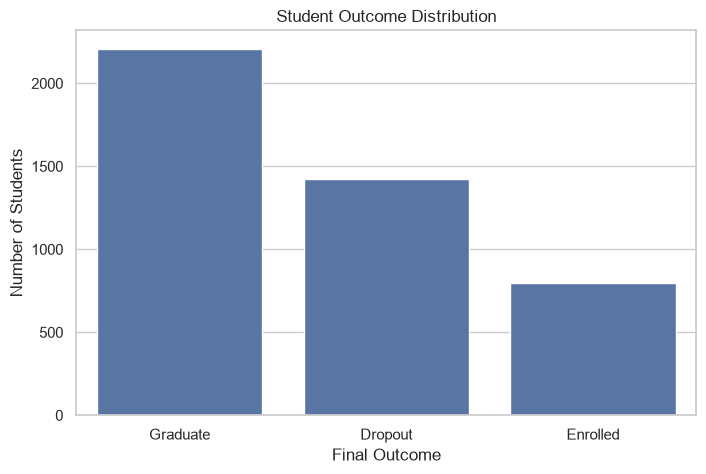

In [60]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Target",
    order=df["Target"].value_counts().index
)

plt.title("Student Outcome Distribution")
plt.xlabel("Final Outcome")
plt.ylabel("Number of Students")

plt.show()


## 5. General numerical summary

In [61]:
display(df.describe().T)

,count,mean,std,min,25%,50%,75%,max
Marital Status,"4,424.00",1.18,0.61,1.00,1.00,1.00,1.00,6.00
Application mode,"4,424.00",18.67,17.48,1.00,1.00,17.00,39.00,57.00
Application order,"4,424.00",1.73,1.31,0.00,1.00,1.00,2.00,9.00
Course,"4,424.00","8,856.64","2,063.57",33.00,"9,085.00","9,238.00","9,556.00","9,991.00"
Daytime/evening attendance,"4,424.00",0.89,0.31,0.00,1.00,1.00,1.00,1.00
Previous qualification,"4,424.00",4.58,10.22,1.00,1.00,1.00,1.00,43.00
Previous qualification (grade),"4,424.00",132.61,13.19,95.00,125.00,133.10,140.00,190.00
Nacionality,"4,424.00",1.87,6.91,1.00,1.00,1.00,1.00,109.00
Mother's qualification,"4,424.00",19.56,15.60,1.00,2.00,19.00,37.00,44.00
Father's qualification,"4,424.00",22.28,15.34,1.00,3.00,19.00,37.00,44.00


## 6. Age at enrollment

In [62]:
display(df["Age at enrollment"].describe())

count   4,424.00
mean       23.27
std         7.59
min        17.00
25%        19.00
50%        20.00
75%        25.00
max        70.00
Name: Age at enrollment, dtype: float64

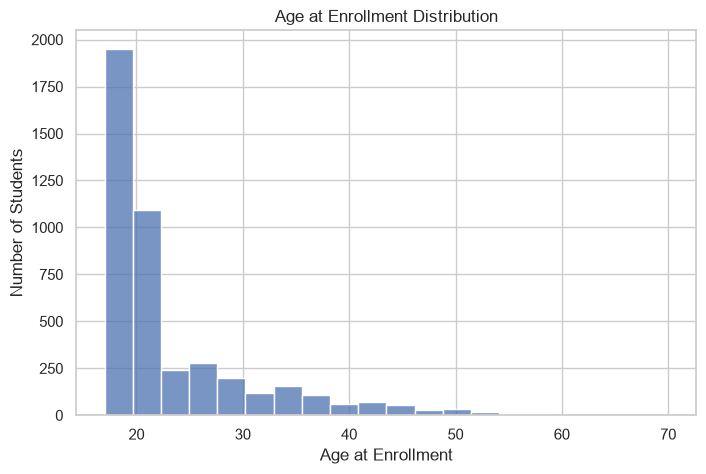

In [63]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="Age at enrollment",
    bins=20
)

plt.title("Age at Enrollment Distribution")
plt.xlabel("Age at Enrollment")
plt.ylabel("Number of Students")

plt.show()


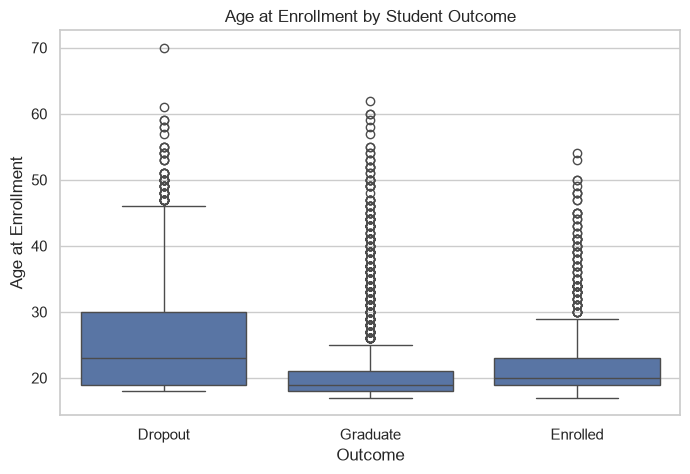

In [64]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Target",
    y="Age at enrollment"
)

plt.title("Age at Enrollment by Student Outcome")
plt.xlabel("Outcome")
plt.ylabel("Age at Enrollment")

plt.show()


## 7. Gender and student outcome

In [65]:
gender_outcomes = pd.crosstab(
    df["Gender"],
    df["Target"],
    normalize="index"
) * 100

display(gender_outcomes)


Target,Dropout,Enrolled,Graduate
Gender,,,
0,25.10,16.98,57.91
1,45.05,19.73,35.22


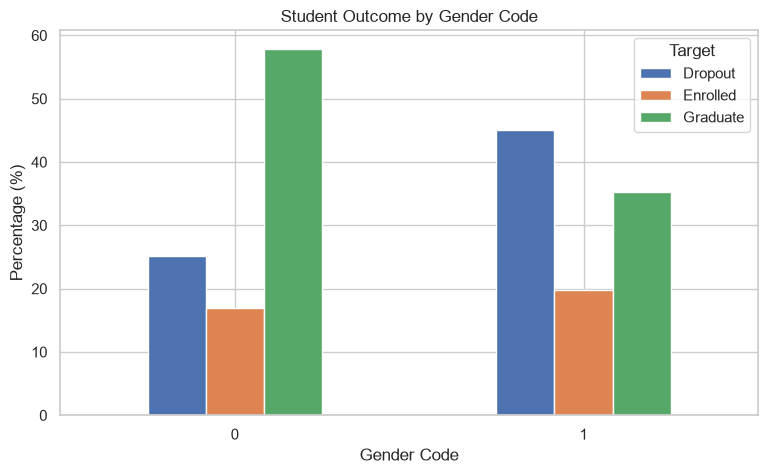

In [66]:
gender_outcomes.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Student Outcome by Gender Code")
plt.xlabel("Gender Code")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)

plt.show()


## 8. Scholarship status and student outcome

In [67]:
scholarship_outcomes = pd.crosstab(
    df["Scholarship holder"],
    df["Target"],
    normalize="index"
) * 100

display(scholarship_outcomes)


Target,Dropout,Enrolled,Graduate
Scholarship holder,,,
0,38.71,19.97,41.32
1,12.19,11.83,75.98


In [68]:
scholarship_dropout = (
    df.groupby("Scholarship holder")["Target"]
    .apply(lambda x: (x == "Dropout").mean() * 100)
)

display(scholarship_dropout)


Scholarship holder
0   38.71
1   12.19
Name: Target, dtype: float64

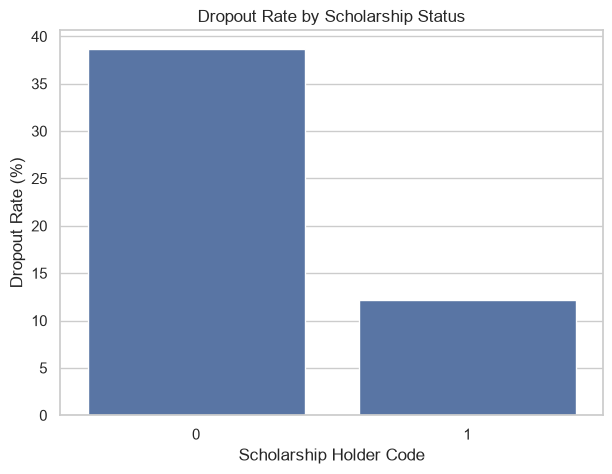

In [69]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=scholarship_dropout.index.astype(str),
    y=scholarship_dropout.values
)

plt.title("Dropout Rate by Scholarship Status")
plt.xlabel("Scholarship Holder Code")
plt.ylabel("Dropout Rate (%)")

plt.show()


## 9. Tuition fee status and student outcome

In [70]:
tuition_outcomes = pd.crosstab(
    df["Tuition fees up to date"],
    df["Target"],
    normalize="index"
) * 100

display(tuition_outcomes)


Target,Dropout,Enrolled,Graduate
Tuition fees up to date,,,
0,86.55,7.95,5.49
1,24.74,19.30,55.95


In [71]:
tuition_dropout = (
    df.groupby("Tuition fees up to date")["Target"]
    .apply(lambda x: (x == "Dropout").mean() * 100)
)

display(tuition_dropout)


Tuition fees up to date
0   86.55
1   24.74
Name: Target, dtype: float64

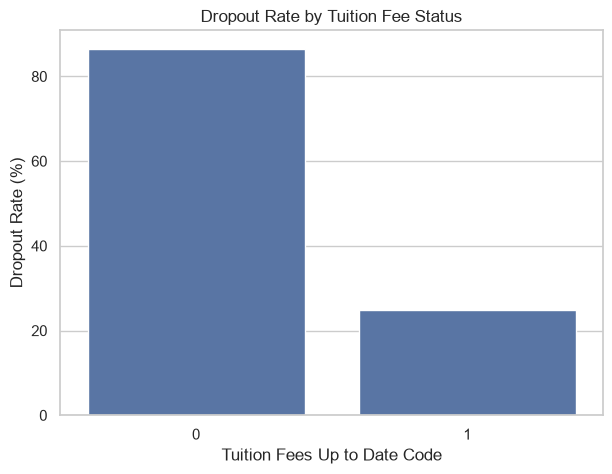

In [72]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=tuition_dropout.index.astype(str),
    y=tuition_dropout.values
)

plt.title("Dropout Rate by Tuition Fee Status")
plt.xlabel("Tuition Fees Up to Date Code")
plt.ylabel("Dropout Rate (%)")

plt.show()


## 10. Scholarship status and tuition fee status together

In [73]:
scholarship_tuition_outcomes = pd.crosstab(
    [
        df["Scholarship holder"],
        df["Tuition fees up to date"]
    ],
    df["Target"],
    normalize="index"
) * 100

display(scholarship_tuition_outcomes)


Target                                      Dropout  Enrolled  Graduate
Scholarship holder Tuition fees up to date                             
0                  0                          89.00      6.85      4.15
                   1                          30.18     22.19     47.63
1                  0                          60.87     19.57     19.57
                   1                          10.07     11.49     78.44

In [74]:
scholarship_tuition_counts = pd.crosstab(
    [
        df["Scholarship holder"],
        df["Tuition fees up to date"]
    ],
    columns="Count"
)

display(scholarship_tuition_counts)


col_0                                       Count
Scholarship holder Tuition fees up to date       
0                  0                          482
                   1                         2843
1                  0                           46
                   1                         1053

## 11. Course-level dropout analysis

Course is represented using numeric category codes.

Both dropout rate and group size are examined. A high dropout percentage from a very small group can be less reliable than a similar percentage from a large group.


In [75]:
course_outcomes = pd.crosstab(
    df["Course"],
    df["Target"],
    normalize="index"
) * 100

course_dropout = course_outcomes["Dropout"].sort_values(
    ascending=False
)

course_summary = pd.DataFrame({
    "Students": df["Course"].value_counts(),
    "Dropout Rate (%)": course_dropout
}).sort_values(
    "Dropout Rate (%)",
    ascending=False
)

display(course_summary)


,Students,Dropout Rate (%)
Course,,
33,12,66.67
9130,141,55.32
9119,170,54.12
9991,268,50.75
9853,192,44.27
9003,210,40.95
9556,86,38.37
171,215,38.14
9254,252,38.10


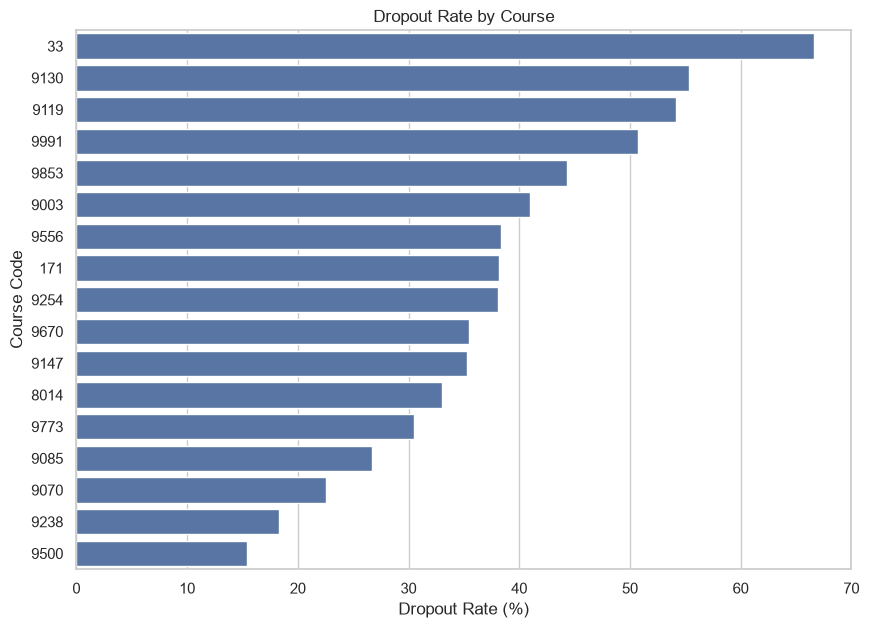

In [76]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=course_dropout.values,
    y=course_dropout.index.astype(str),
    orient="h"
)

plt.title("Dropout Rate by Course")
plt.xlabel("Dropout Rate (%)")
plt.ylabel("Course Code")

plt.show()


In [77]:
course_summary_50plus = course_summary[
    course_summary["Students"] >= 50
].sort_values(
    "Dropout Rate (%)",
    ascending=False
)

display(course_summary_50plus)


,Students,Dropout Rate (%)
Course,,
9130,141,55.32
9119,170,54.12
9991,268,50.75
9853,192,44.27
9003,210,40.95
9556,86,38.37
171,215,38.14
9254,252,38.10
9670,268,35.45


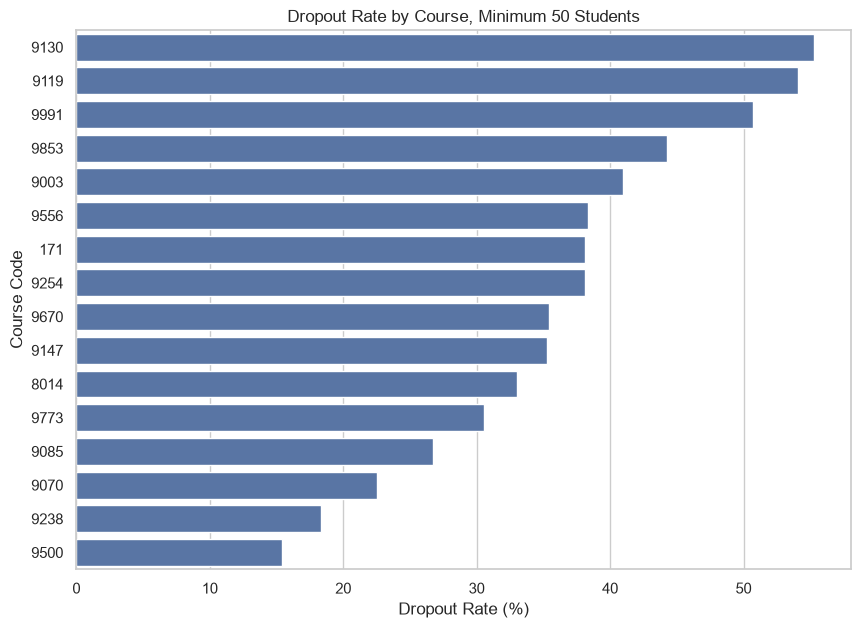

In [78]:
plt.figure(figsize=(10, 7))

sns.barplot(
    x=course_summary_50plus["Dropout Rate (%)"],
    y=course_summary_50plus.index.astype(str),
    orient="h"
)

plt.title("Dropout Rate by Course, Minimum 50 Students")
plt.xlabel("Dropout Rate (%)")
plt.ylabel("Course Code")

plt.show()


## 12. Admission grade and previous qualification grade

In [79]:
display(df["Admission grade"].describe())
display(df["Previous qualification (grade)"].describe())


count   4,424.00
mean      126.98
std        14.48
min        95.00
25%       117.90
50%       126.10
75%       134.80
max       190.00
Name: Admission grade, dtype: float64

count   4,424.00
mean      132.61
std        13.19
min        95.00
25%       125.00
50%       133.10
75%       140.00
max       190.00
Name: Previous qualification (grade), dtype: float64

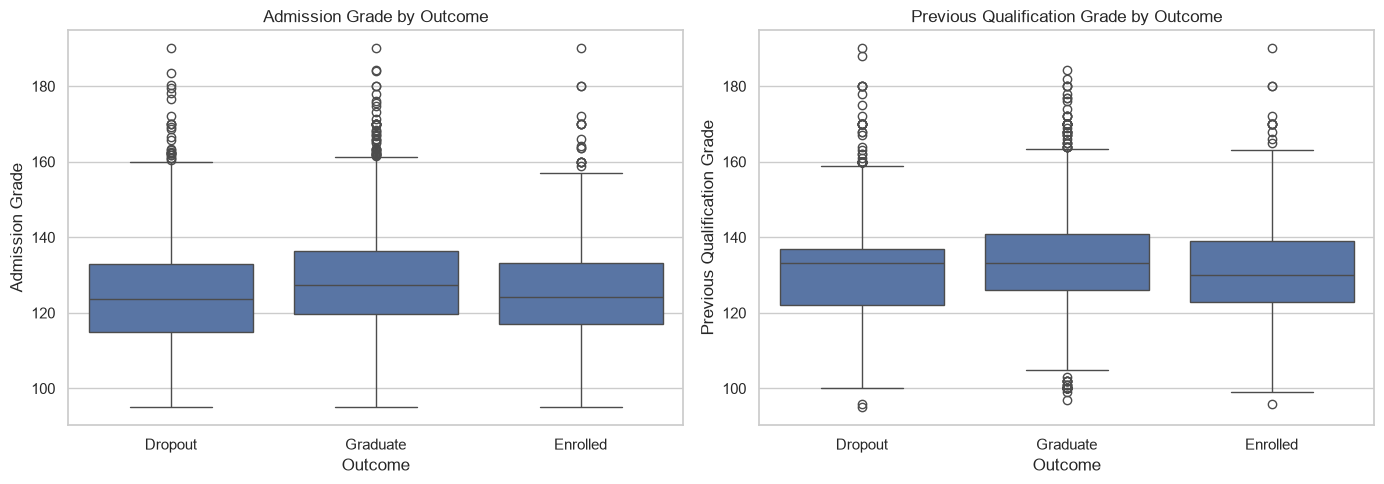

In [80]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(
    data=df,
    x="Target",
    y="Admission grade",
    ax=axes[0]
)

axes[0].set_title("Admission Grade by Outcome")
axes[0].set_xlabel("Outcome")
axes[0].set_ylabel("Admission Grade")

sns.boxplot(
    data=df,
    x="Target",
    y="Previous qualification (grade)",
    ax=axes[1]
)

axes[1].set_title("Previous Qualification Grade by Outcome")
axes[1].set_xlabel("Outcome")
axes[1].set_ylabel("Previous Qualification Grade")

plt.tight_layout()
plt.show()


## 13. First-semester academic performance

These variables describe academic activity during the first semester.

They are appropriate candidates for the later Semester 1 prediction model, but they are not available at the time of enrollment.


In [81]:
first_sem_cols = [
    "Curricular units 1st sem (credited)",
    "Curricular units 1st sem (enrolled)",
    "Curricular units 1st sem (evaluations)",
    "Curricular units 1st sem (approved)",
    "Curricular units 1st sem (grade)",
    "Curricular units 1st sem (without evaluations)"
]

display(df[first_sem_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Curricular units 1st sem (credited),"4,424.00",0.71,2.36,0.00,0.00,0.00,0.00,20.00
Curricular units 1st sem (enrolled),"4,424.00",6.27,2.48,0.00,5.00,6.00,7.00,26.00
Curricular units 1st sem (evaluations),"4,424.00",8.30,4.18,0.00,6.00,8.00,10.00,45.00
Curricular units 1st sem (approved),"4,424.00",4.71,3.09,0.00,3.00,5.00,6.00,26.00
Curricular units 1st sem (grade),"4,424.00",10.64,4.84,0.00,11.00,12.29,13.40,18.88
Curricular units 1st sem (without evaluations),"4,424.00",0.14,0.69,0.00,0.00,0.00,0.00,12.00


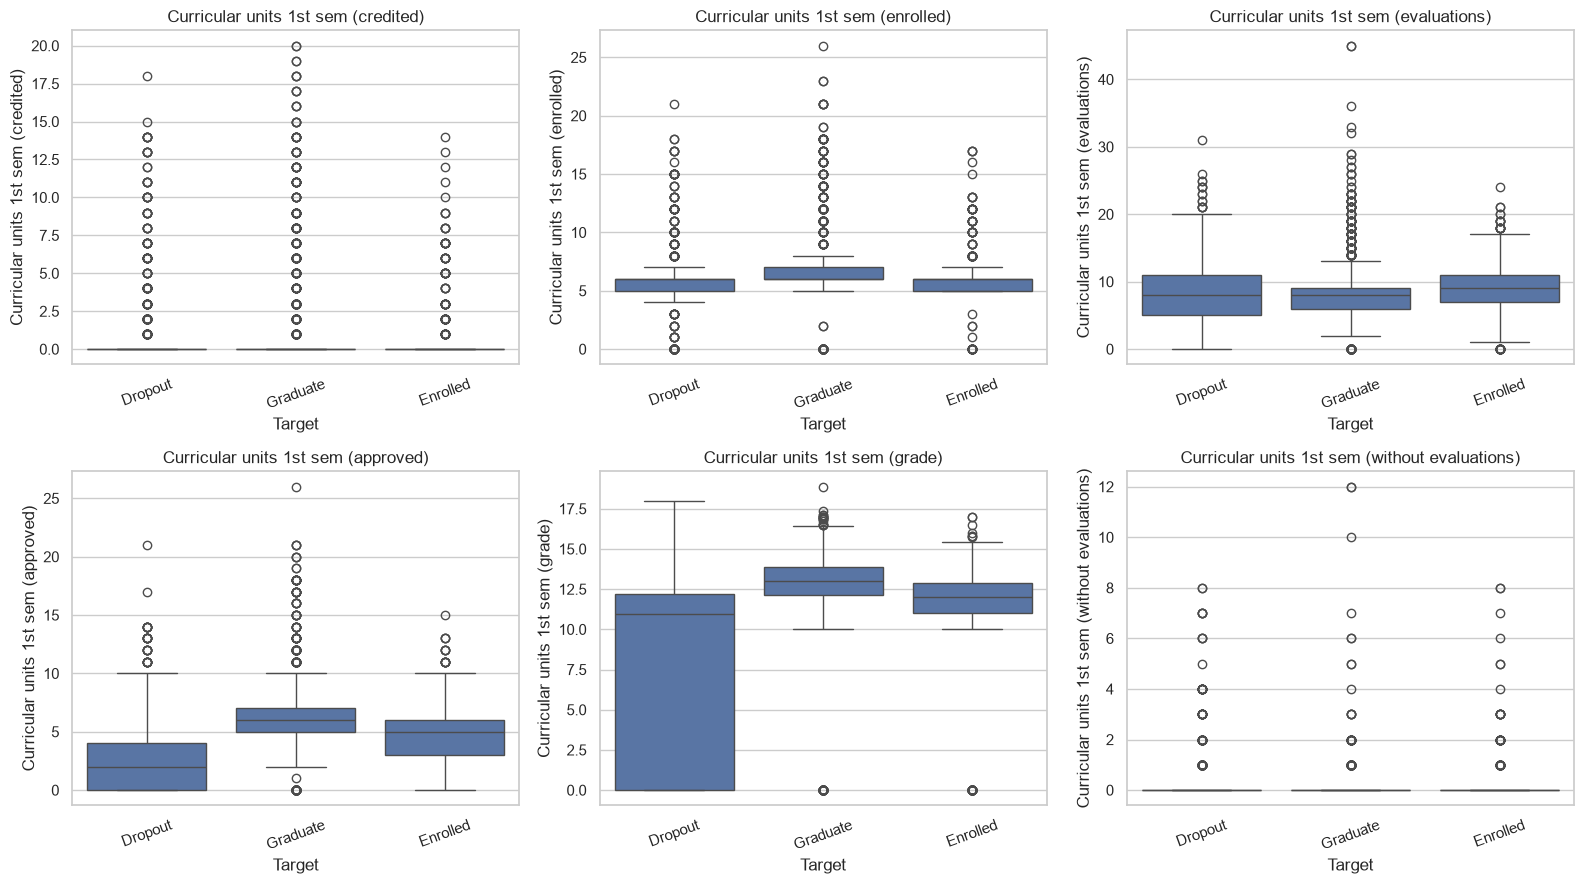

In [82]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), first_sem_cols):
    sns.boxplot(
        data=df,
        x="Target",
        y=col,
        ax=ax
    )
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


In [83]:
first_sem_means = df.groupby("Target")[first_sem_cols].mean().T
display(first_sem_means)


Target,Dropout,Enrolled,Graduate
Curricular units 1st sem (credited),0.61,0.51,0.85
Curricular units 1st sem (enrolled),5.82,5.96,6.67
Curricular units 1st sem (evaluations),7.75,9.34,8.28
Curricular units 1st sem (approved),2.55,4.32,6.23
Curricular units 1st sem (grade),7.26,11.13,12.64
Curricular units 1st sem (without evaluations),0.19,0.18,0.09


## 14. First-semester engineered ratios

In [84]:
df_eda = df.copy()

df_eda["1st_sem_approval_rate"] = np.where(
    df_eda["Curricular units 1st sem (enrolled)"] > 0,
    df_eda["Curricular units 1st sem (approved)"] /
    df_eda["Curricular units 1st sem (enrolled)"],
    np.nan
)

df_eda["1st_sem_evaluation_rate"] = np.where(
    df_eda["Curricular units 1st sem (enrolled)"] > 0,
    df_eda["Curricular units 1st sem (evaluations)"] /
    df_eda["Curricular units 1st sem (enrolled)"],
    np.nan
)

display(
    df_eda[
        ["1st_sem_approval_rate", "1st_sem_evaluation_rate"]
    ].describe()
)


,1st_sem_approval_rate,1st_sem_evaluation_rate
count,"4,244.00","4,244.00"
mean,0.73,1.35
std,0.34,0.51
min,0.00,0.00
25%,0.60,1.00
50%,0.86,1.23
75%,1.00,1.60
max,1.00,3.50


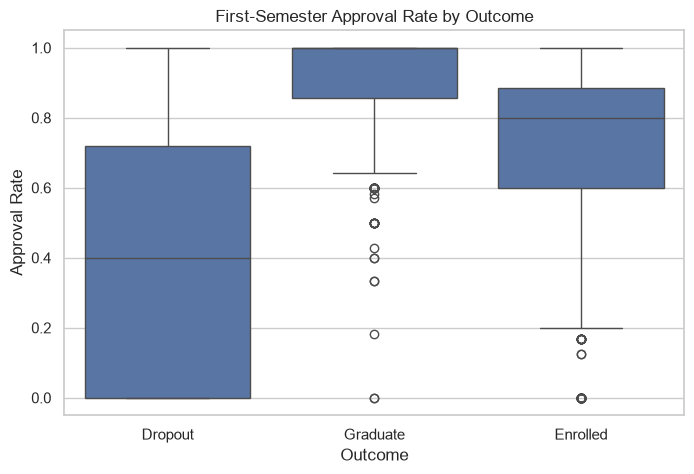

In [85]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_eda,
    x="Target",
    y="1st_sem_approval_rate"
)

plt.title("First-Semester Approval Rate by Outcome")
plt.xlabel("Outcome")
plt.ylabel("Approval Rate")

plt.show()


## 15. Second-semester academic performance

Second-semester variables are useful for understanding the dataset, but they occur later in the student's journey.

They will not be used in an early-warning model that claims to predict outcomes at enrollment or immediately after Semester 1.


In [86]:
second_sem_cols = [
    "Curricular units 2nd sem (credited)",
    "Curricular units 2nd sem (enrolled)",
    "Curricular units 2nd sem (evaluations)",
    "Curricular units 2nd sem (approved)",
    "Curricular units 2nd sem (grade)",
    "Curricular units 2nd sem (without evaluations)"
]

display(df[second_sem_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Curricular units 2nd sem (credited),"4,424.00",0.54,1.92,0.00,0.00,0.00,0.00,19.00
Curricular units 2nd sem (enrolled),"4,424.00",6.23,2.20,0.00,5.00,6.00,7.00,23.00
Curricular units 2nd sem (evaluations),"4,424.00",8.06,3.95,0.00,6.00,8.00,10.00,33.00
Curricular units 2nd sem (approved),"4,424.00",4.44,3.01,0.00,2.00,5.00,6.00,20.00
Curricular units 2nd sem (grade),"4,424.00",10.23,5.21,0.00,10.75,12.20,13.33,18.57
Curricular units 2nd sem (without evaluations),"4,424.00",0.15,0.75,0.00,0.00,0.00,0.00,12.00


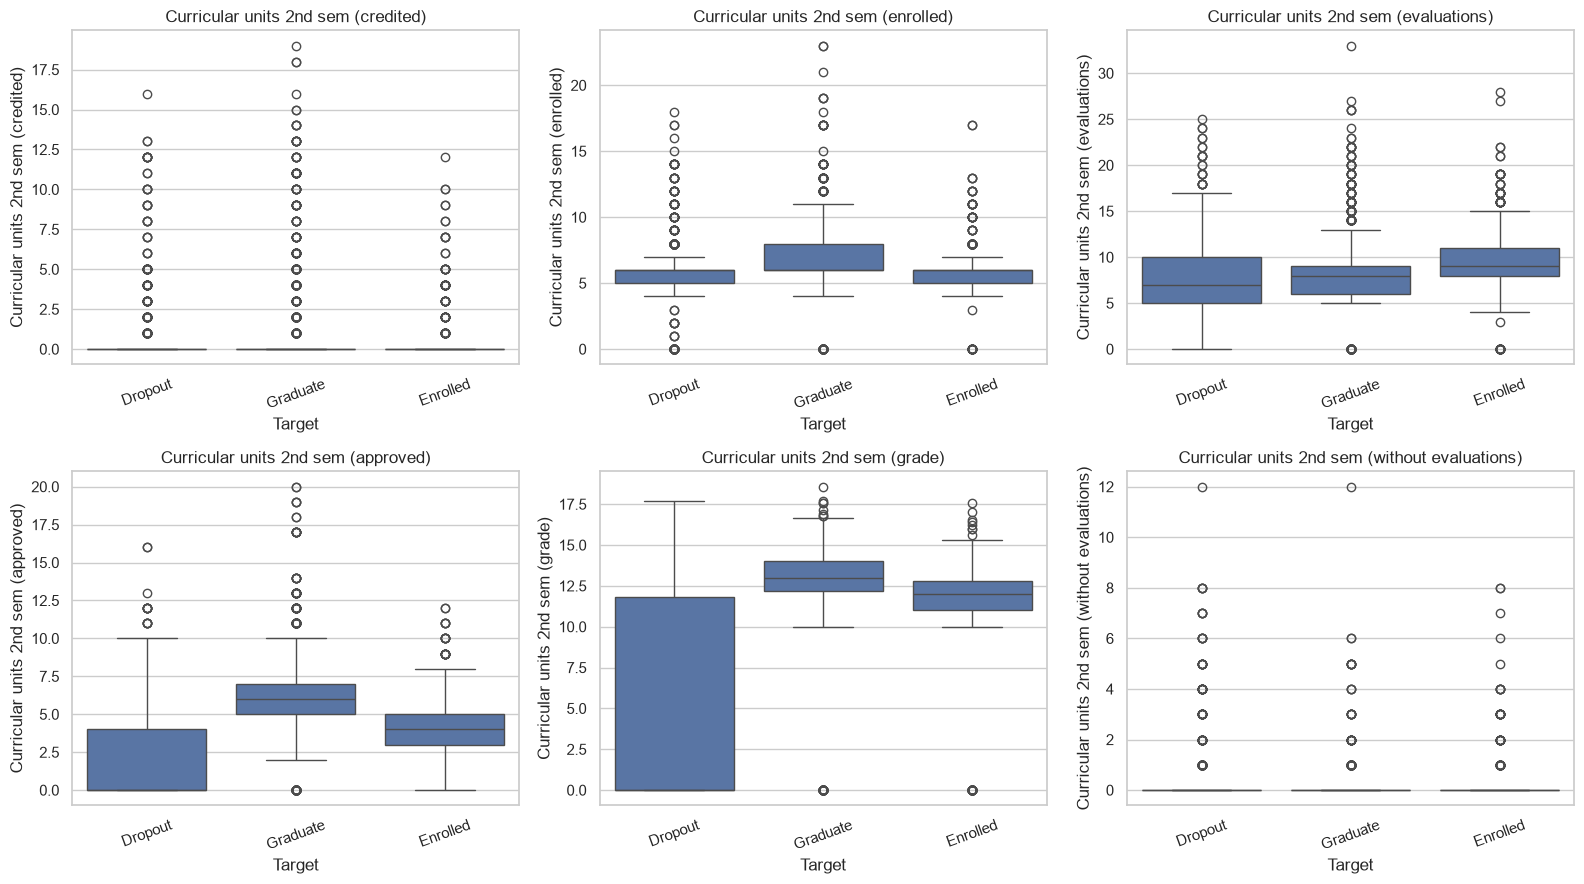

In [87]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

for ax, col in zip(axes.flatten(), second_sem_cols):
    sns.boxplot(
        data=df,
        x="Target",
        y=col,
        ax=ax
    )
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 16. Other student context variables

In [88]:
context_cols = [
    "Debtor",
    "Displaced",
    "Educational special needs",
    "International"
]

for col in context_cols:
    print(f"===== {col} =====")
    display(
        pd.crosstab(
            df[col],
            df["Target"],
            normalize="index"
        ) * 100
    )


===== Debtor =====


Target,Dropout,Enrolled,Graduate
Debtor,,,
0,28.28,17.95,53.76
1,62.03,17.89,20.08


===== Displaced =====


Target,Dropout,Enrolled,Graduate
Displaced,,,
0,37.64,18.07,44.29
1,27.58,17.85,54.58


===== Educational special needs =====


Target,Dropout,Enrolled,Graduate
Educational special needs,,,
0,32.11,17.91,49.99
1,33.33,21.57,45.10


===== International =====


Target,Dropout,Enrolled,Graduate
International,,,
0,32.20,17.85,49.95
1,29.09,21.82,49.09


## 17. Macroeconomic variables

In [89]:
macro_cols = [
    "Unemployment rate",
    "Inflation rate",
    "GDP"
]

display(df[macro_cols].describe().T)


,count,mean,std,min,25%,50%,75%,max
Unemployment rate,"4,424.00",11.57,2.66,7.60,9.40,11.10,13.90,16.20
Inflation rate,"4,424.00",1.23,1.38,-0.80,0.30,1.40,2.60,3.70
GDP,"4,424.00",0.00,2.27,-4.06,-1.70,0.32,1.79,3.51


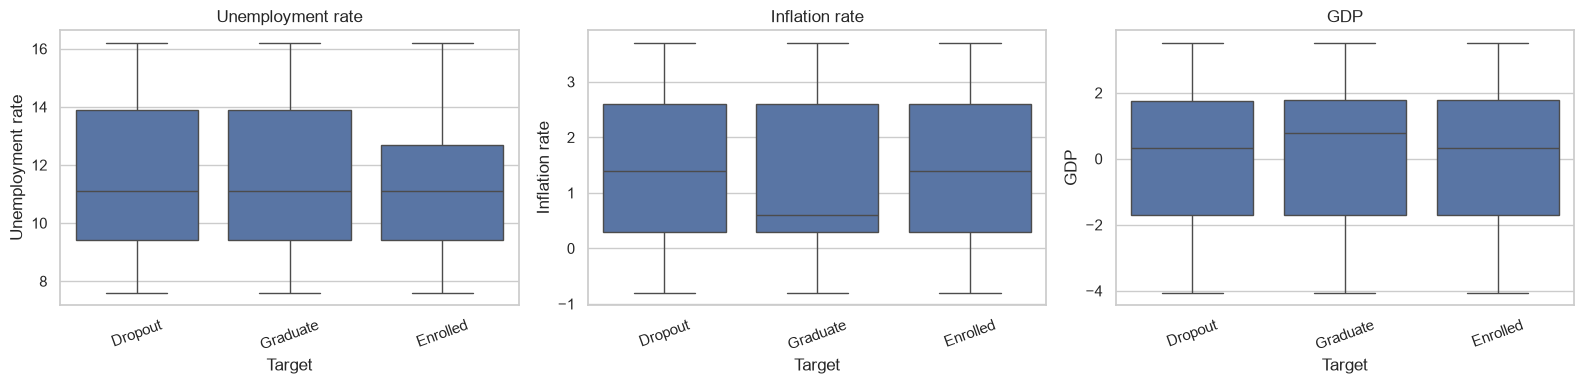

In [90]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, macro_cols):
    sns.boxplot(
        data=df,
        x="Target",
        y=col,
        ax=ax
    )
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


## 18. Correlation analysis

This heatmap is exploratory.

Correlation does not prove causation. Numeric codes representing categories should also not automatically be interpreted as continuous numerical measurements.


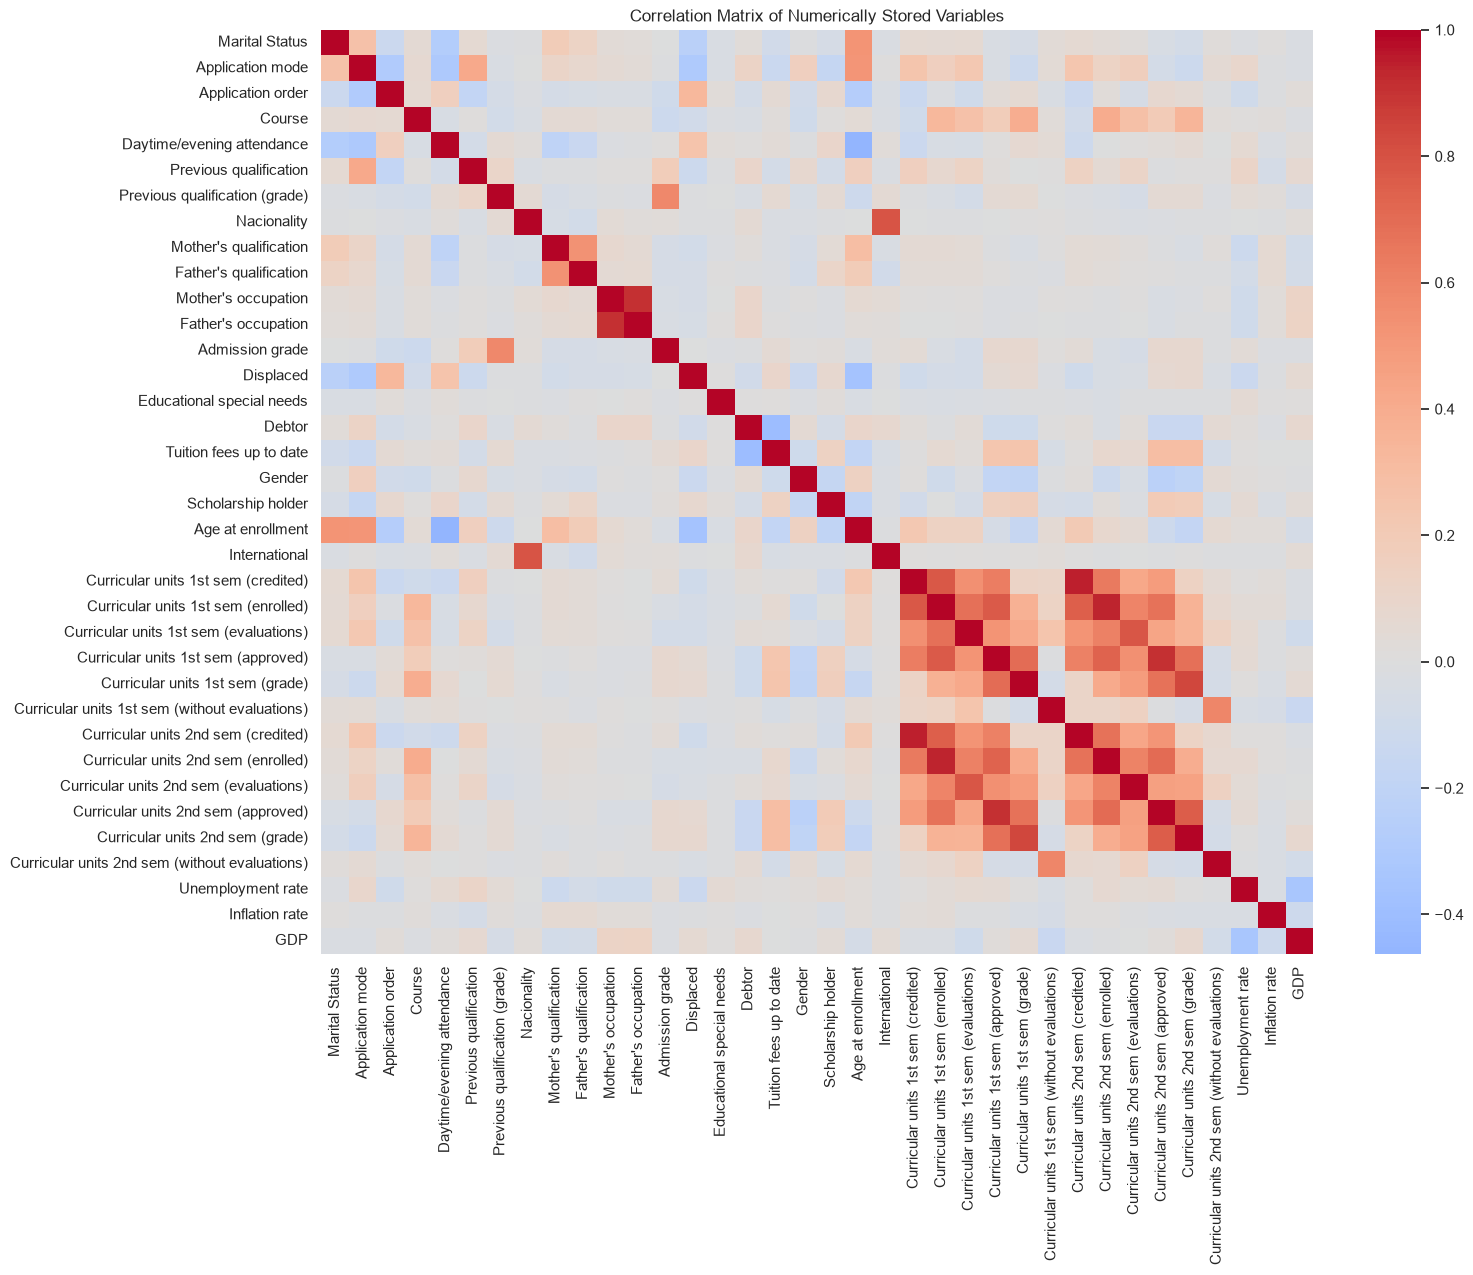

In [91]:
numeric_df = df.select_dtypes(include=np.number)
corr = numeric_df.corr()

plt.figure(figsize=(16, 12))

sns.heatmap(
    corr,
    center=0,
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Numerically Stored Variables")
plt.show()


## 19. Numerical variables by student outcome

In [92]:
numeric_by_target = df.groupby(
    "Target"
)[numeric_df.columns].mean().T

display(numeric_by_target)


Target,Dropout,Enrolled,Graduate
Marital Status,1.26,1.15,1.13
Application mode,23.71,19.80,15.02
Application order,1.59,1.63,1.85
Course,"8,755.63","8,868.81","8,917.25"
Daytime/evening attendance,0.85,0.91,0.91
Previous qualification,5.31,4.79,4.03
Previous qualification (grade),131.11,131.21,134.08
Nacionality,1.96,2.08,1.75
Mother's qualification,21.04,17.62,19.31
Father's qualification,22.68,20.92,22.50


## 20. Chi-square tests

A chi-square test can be used here to test whether selected categorical variables and the target show evidence of statistical association.

A small p-value does not establish causation.

Statistical significance also does not automatically mean that a relationship is practically important.


In [93]:
from scipy.stats import chi2_contingency

categorical_test_cols = [
    "Gender",
    "Scholarship holder",
    "Tuition fees up to date",
    "Debtor",
    "International",
    "Displaced"
]

chi_square_results = []

for col in categorical_test_cols:
    table = pd.crosstab(df[col], df["Target"])

    chi2, p_value, dof, expected = chi2_contingency(table)

    chi_square_results.append({
        "Variable": col,
        "Chi-square": chi2,
        "p-value": p_value,
        "Degrees of freedom": dof
    })

chi_square_results = pd.DataFrame(
    chi_square_results
).sort_values("p-value")

display(chi_square_results)


,Variable,Chi-square,p-value,Degrees of freedom
2,Tuition fees up to date,823.55,0.00,2
1,Scholarship holder,409.94,0.00,2
3,Debtor,259.33,0.00,2
0,Gender,233.27,0.00,2
5,Displaced,57.75,0.00,2
4,International,1.28,0.53,2


## 21. Prediction stages

The project uses two prediction stages.

### Stage 1: Enrollment-only prediction

Only information available when a student enrolls is used.

### Stage 2: Semester 1 prediction

Enrollment information is combined with first-semester academic information.

Second-semester information is excluded from both early prediction stages.

This creates a useful comparison:

**How much can be predicted at enrollment, and how much does prediction improve after the first semester?**


In [94]:
semester_cols = [
    col for col in df.columns
    if "1st sem" in col.lower() or "2nd sem" in col.lower()
]

second_sem_only_cols = [
    col for col in df.columns
    if "2nd sem" in col.lower()
]

enrollment_only_df = df.drop(columns=semester_cols)
semester1_df = df.drop(columns=second_sem_only_cols)

print("Original dataset:", df.shape)
print("Enrollment-only dataset:", enrollment_only_df.shape)
print("Semester 1 dataset:", semester1_df.shape)


Original dataset: (4424, 37)
Enrollment-only dataset: (4424, 25)
Semester 1 dataset: (4424, 31)


In [95]:
enrollment_only_df.to_csv(
    "../data/processed/enrollment_only.csv",
    index=False
)

semester1_df.to_csv(
    "../data/processed/semester1.csv",
    index=False
)

print("Processed datasets saved successfully.")


Processed datasets saved successfully.


# 22. EDA Findings

This section will contain the main findings from the analysis.

### Finding 1
**Observation:** 

**Evidence:** 

**Interpretation:** 

**Caution:** 

### Finding 2
**Observation:** 

**Evidence:** 

**Interpretation:** 

**Caution:** 

### Finding 3
**Observation:** 

**Evidence:** 

**Interpretation:** 

**Caution:** 

Additional findings can be added using the same structure.


# 23. Project checkpoint

At the end of this notebook, the following should be understood:

- dataset size and structure
- data quality
- target distribution
- important demographic patterns
- financial patterns
- course-level differences
- admission and previous academic performance
- first-semester academic patterns
- second-semester academic patterns
- contextual and economic variables
- candidate relationships worth investigating
- the difference between enrollment-time and Semester 1 prediction

The next stage is the machine learning pipeline:

1. Define features and target
2. Split training and test data
3. Build preprocessing pipelines
4. Establish a baseline
5. Train Logistic Regression
6. Train Decision Tree
7. Train Random Forest
8. Compare precision, recall, F1 and macro F1
9. Examine the confusion matrix
10. Interpret the best model
